# Notebook 10: Comprehensive Model Evaluation and Comparison

**Purpose:** Compare all trained models (baseline vs final optimized) with performance metrics, visualizations, and confusion matrices

**Key Sections:**
1. Baseline model comparison (classical + neural)
2. Final optimized models with full improvements (tuning + feature optimization + ensembles)
3. Best model per algorithm comparison
4. Confusion matrices for best baseline and best overall models
5. Comprehensive summary and recommendations

---

## 1. Import Libraries and Setup

In [1]:
import os
import sys
from pathlib import Path
import json

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# ML evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print('✓ Libraries imported')

✓ Libraries imported


## 2. Project Setup and Load Results

In [2]:
# Project paths
PROJECT_ROOT = Path('..').resolve()
RESULTS_DIR = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'
DATA_DIR = PROJECT_ROOT / 'data'

print(f'Project root: {PROJECT_ROOT}')
print(f'Results directory: {RESULTS_DIR}')
print(f'Models directory: {MODELS_DIR}')

# Create output directory for this notebook's figures
OUTPUT_DIR = RESULTS_DIR / 'evaluation_figures'
OUTPUT_DIR.mkdir(exist_ok=True)
print(f'\nOutput directory created: {OUTPUT_DIR}')

Project root: /Users/harryirving/Development/projects/ai-ml/BikeAIv5
Results directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results
Models directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/models

Output directory created: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/evaluation_figures


In [3]:
# Load all result CSV files

# Baseline results (classical - use combined for main baseline)
baseline_combined = pd.read_csv(RESULTS_DIR / '05_baseline_results_combined.csv')
print('✓ Loaded baseline results')

# Final optimized results (after ALL optimization steps)
final_optimized = pd.read_csv(RESULTS_DIR / '06a_comprehensive_results.csv')
print('✓ Loaded final optimized results (post-tuning + feature optimization)')

# Neural results (1-channel)
neural_1ch = pd.read_csv(RESULTS_DIR / '07_neural_models_results.csv')
print('✓ Loaded 1-channel neural results')

# Neural results (3-channel)
neural_3ch_path = RESULTS_DIR / '07_neural_models_results_3ch.csv'
if neural_3ch_path.exists():
    neural_3ch = pd.read_csv(neural_3ch_path)
    print('✓ Loaded 3-channel neural results')
else:
    neural_3ch = None
    print('⚠️  No 3-channel neural results found')

# Model sizes
model_sizes = pd.read_csv(RESULTS_DIR / '06a_model_sizes.csv')
print('✓ Loaded model sizes')

print(f'\n📊 Dataset summary:')
print(f'  Baseline models: {len(baseline_combined)}')
print(f'  Final optimized models: {len(final_optimized)}')
print(f'  Neural models (1-ch): {len(neural_1ch)}')
if neural_3ch is not None:
    print(f'  Neural models (3-ch): {len(neural_3ch)}')

✓ Loaded baseline results
✓ Loaded final optimized results (post-tuning + feature optimization)
✓ Loaded 1-channel neural results
✓ Loaded 3-channel neural results
✓ Loaded model sizes

📊 Dataset summary:
  Baseline models: 6
  Final optimized models: 18
  Neural models (1-ch): 1
  Neural models (3-ch): 4


## 3. Baseline Models Comparison

Compare all baseline (untuned) classical and neural models.

In [4]:
# Prepare baseline comparison dataframe

def prepare_baseline_comparison():
    """Combine classical and neural baseline results"""
    
    # Classical models (use combined feature set for main comparison)
    classical = baseline_combined.copy()
    classical['Type'] = 'Classical'
    classical['Feature Set'] = 'Combined'
    classical['Model Size (MB)'] = np.nan
    classical['Params'] = np.nan
    
    classical_clean = classical[['Model', 'Test Acc', 'Test F1', 'Train Time (s)', 
                                  'Type', 'Feature Set', 'Model Size (MB)', 'Params']].copy()
    classical_clean.columns = ['Model', 'Accuracy', 'F1', 'Train Time (s)', 
                                'Type', 'Feature Set', 'Size (MB)', 'Params']
    
    # Neural models (1-channel)
    neural_1 = neural_1ch.copy()
    neural_1['Type'] = 'Neural'
    neural_1['Feature Set'] = '1-ch Spectrogram'
    neural_1['Train Time (s)'] = neural_1['Train Time (min)'] * 60
    neural_1['Model'] = neural_1['Model'] + ' (1ch)'
    
    neural_1_clean = neural_1[['Model', 'Accuracy', 'F1', 'Train Time (s)', 
                                'Type', 'Feature Set', 'Size (MB)', 'Params']].copy()
    
    frames = [classical_clean, neural_1_clean]
    
    # Neural models (3-channel) if available
    if neural_3ch is not None:
        neural_3 = neural_3ch.copy()
        neural_3['Type'] = 'Neural'
        neural_3['Feature Set'] = '3-ch Spectrogram'
        neural_3['Train Time (s)'] = neural_3['Train Time (min)'] * 60
        neural_3['Model'] = neural_3['Model'] + ' (3ch)'
        
        neural_3_clean = neural_3[['Model', 'Accuracy', 'F1', 'Train Time (s)', 
                                    'Type', 'Feature Set', 'Size (MB)', 'Params']].copy()
        frames.append(neural_3_clean)
    
    # Combine all
    baseline_all = pd.concat(frames, ignore_index=True)
    
    return baseline_all

baseline_comparison = prepare_baseline_comparison()

# Display table
print('\n' + '='*80)
print('BASELINE MODELS COMPARISON')
print('='*80 + '\n')

display(baseline_comparison.sort_values('F1', ascending=False).round(4))


BASELINE MODELS COMPARISON



,Model,Accuracy,F1,Train Time (s),Type,Feature Set,Size (MB),Params
2,XGBoost,0.9866,0.9879,1.5872,Classical,Combined,NaN,NaN
1,Random Forest,0.9785,0.9805,9.8784,Classical,Combined,NaN,NaN
7,CNN_LSTM (3ch),0.9779,0.9799,655.4336,Neural,3-ch Spectrogram,1.3881,115713.0
3,Gradient Boosting,0.9725,0.9750,326.9261,Classical,Combined,NaN,NaN
8,CNN1D (3ch),0.9725,0.9750,455.9504,Neural,3-ch Spectrogram,1.1255,93057.0
9,LSTM (3ch),0.9686,0.9714,2506.7752,Neural,3-ch Spectrogram,2.1084,179777.0
4,KNN,0.9580,0.9611,0.0131,Classical,Combined,NaN,NaN
0,LinearSVC,0.9384,0.9438,8.9864,Classical,Combined,NaN,NaN
6,MLP (1ch),0.8724,0.8858,303.0085,Neural,1-ch Spectrogram,36.0437,3145729.0
10,MLP (3ch),0.8510,0.8584,171.7164,Neural,3-ch Spectrogram,36.0436,3145729.0


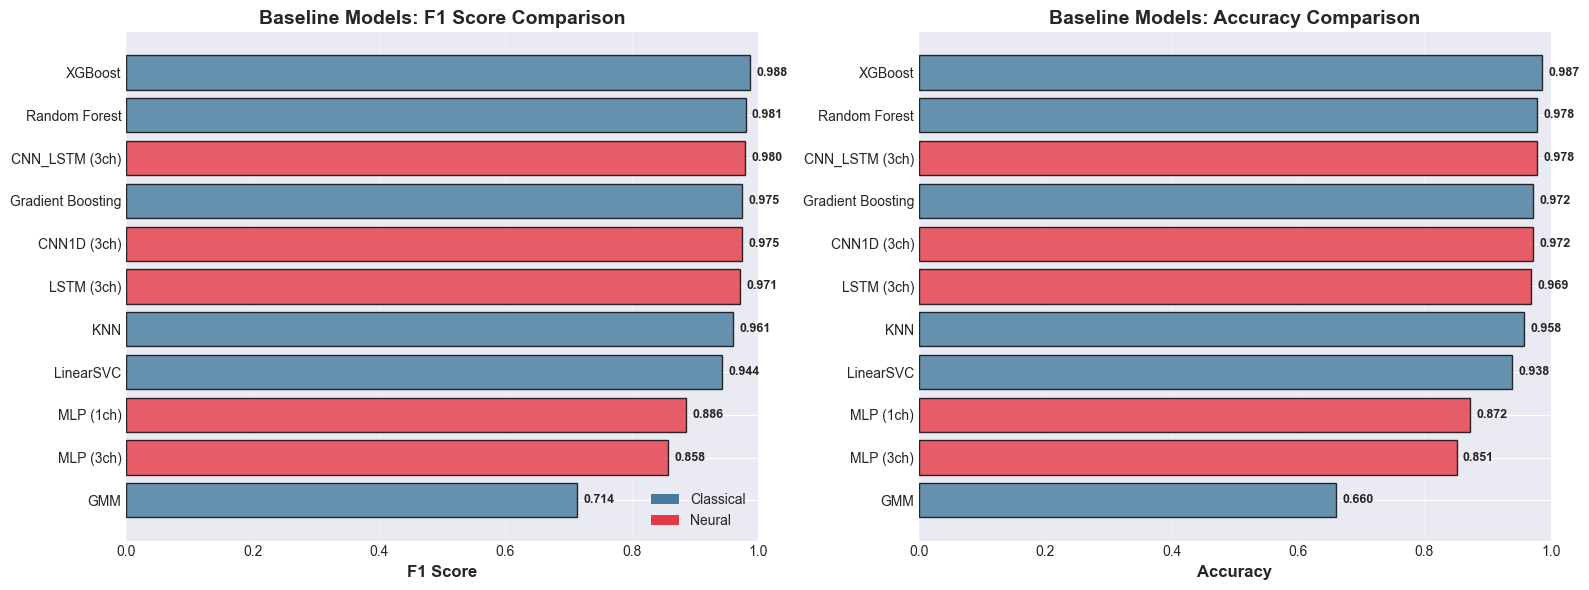


✓ Figure saved to /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/evaluation_figures/01_baseline_comparison.png


In [5]:
# Baseline comparison bar chart

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

baseline_sorted = baseline_comparison.sort_values('F1', ascending=True)

# Color by type
colors = baseline_sorted['Type'].map({'Classical': '#457B9D', 'Neural': '#E63946'})

# Plot 1: F1 Score
axes[0].barh(baseline_sorted['Model'], baseline_sorted['F1'], color=colors, alpha=0.8, edgecolor='black')
axes[0].set_xlabel('F1 Score', fontsize=12, fontweight='bold')
axes[0].set_title('Baseline Models: F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1.0)
axes[0].grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(baseline_sorted.iterrows()):
    axes[0].text(row['F1'] + 0.01, i, f"{row['F1']:.3f}", 
                va='center', fontsize=9, fontweight='bold')

# Plot 2: Accuracy
axes[1].barh(baseline_sorted['Model'], baseline_sorted['Accuracy'], color=colors, alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Baseline Models: Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1.0)
axes[1].grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(baseline_sorted.iterrows()):
    axes[1].text(row['Accuracy'] + 0.01, i, f"{row['Accuracy']:.3f}", 
                va='center', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#457B9D', label='Classical'),
                   Patch(facecolor='#E63946', label='Neural')]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n✓ Figure saved to {OUTPUT_DIR / "01_baseline_comparison.png"}')

## 4. Final Optimized Models Comparison

Compare final optimized models (after tuning + feature optimization + ensembles) with baseline.

In [6]:
# Prepare final optimized comparison

def prepare_final_comparison():
    """Compare final optimized models with their baseline counterparts"""
    
    comparison_list = []
    
    # Use COMBINED feature set results as primary comparison
    final_combined = final_optimized[final_optimized['Feature Set'] == 'COMBINED'].copy()
    
    for idx, final_row in final_combined.iterrows():
        model_name = final_row['Model']
        model_type = final_row['Type']  # Individual or Ensemble
        
        # For ensembles, skip (no baseline comparison)
        if model_type == 'Ensemble':
            # Add ensemble as new entry with no baseline
            comparison_list.append({
                'Model': model_name,
                'Type': 'Ensemble',
                'Baseline Acc': np.nan,
                'Final Acc': final_row['Test Accuracy'],
                'Acc Δ': np.nan,
                'Acc Δ %': np.nan,
                'Baseline F1': np.nan,
                'Final F1': final_row['Test F1'],
                'F1 Δ': np.nan,
                'F1 Δ %': np.nan
            })
            continue
        
        # For individual models, find corresponding baseline
        baseline_row = baseline_combined[baseline_combined['Model'] == model_name]
        
        if not baseline_row.empty:
            baseline_row = baseline_row.iloc[0]
            
            acc_delta = final_row['Test Accuracy'] - baseline_row['Test Acc']
            f1_delta = final_row['Test F1'] - baseline_row['Test F1']
            
            comparison_list.append({
                'Model': model_name,
                'Type': 'Individual',
                'Baseline Acc': baseline_row['Test Acc'],
                'Final Acc': final_row['Test Accuracy'],
                'Acc Δ': acc_delta,
                'Acc Δ %': (acc_delta / baseline_row['Test Acc']) * 100,
                'Baseline F1': baseline_row['Test F1'],
                'Final F1': final_row['Test F1'],
                'F1 Δ': f1_delta,
                'F1 Δ %': (f1_delta / baseline_row['Test F1']) * 100
            })
    
    # Add neural models (no baseline comparison, just show as final)
    for idx, neural_row in neural_1ch.iterrows():
        comparison_list.append({
            'Model': neural_row['Model'] + ' (1ch)',
            'Type': 'Neural',
            'Baseline Acc': np.nan,
            'Final Acc': neural_row['Accuracy'],
            'Acc Δ': np.nan,
            'Acc Δ %': np.nan,
            'Baseline F1': np.nan,
            'Final F1': neural_row['F1'],
            'F1 Δ': np.nan,
            'F1 Δ %': np.nan
        })
    
    if neural_3ch is not None:
        for idx, neural_row in neural_3ch.iterrows():
            comparison_list.append({
                'Model': neural_row['Model'] + ' (3ch)',
                'Type': 'Neural',
                'Baseline Acc': np.nan,
                'Final Acc': neural_row['Accuracy'],
                'Acc Δ': np.nan,
                'Acc Δ %': np.nan,
                'Baseline F1': np.nan,
                'Final F1': neural_row['F1'],
                'F1 Δ': np.nan,
                'F1 Δ %': np.nan
            })
    
    return pd.DataFrame(comparison_list)

final_comparison = prepare_final_comparison()

# Display table
print('\n' + '='*100)
print('FINAL OPTIMIZED MODELS (vs Baseline)')
print('All improvements include: hyperparameter tuning + feature optimization + ensembles')
print('='*100 + '\n')

# Style the dataframe
def highlight_improvements(val):
    if isinstance(val, (int, float)) and not np.isnan(val):
        if val > 0:
            return 'color: green; font-weight: bold'
        elif val < 0:
            return 'color: red; font-weight: bold'
    return ''

styled_df = final_comparison.sort_values('Final F1', ascending=False).style.applymap(
    highlight_improvements, 
    subset=['Acc Δ', 'Acc Δ %', 'F1 Δ', 'F1 Δ %']
)

display(styled_df.format({
    'Baseline Acc': '{:.4f}',
    'Final Acc': '{:.4f}',
    'Acc Δ': '{:.4f}',
    'Acc Δ %': '{:+.2f}%',
    'Baseline F1': '{:.4f}',
    'Final F1': '{:.4f}',
    'F1 Δ': '{:.4f}',
    'F1 Δ %': '{:+.2f}%'
}, na_rep='—'))


FINAL OPTIMIZED MODELS (vs Baseline)
All improvements include: hyperparameter tuning + feature optimization + ensembles



,Model,Type,Baseline Acc,Final Acc,Acc Δ,Acc Δ %,Baseline F1,Final F1,F1 Δ,F1 Δ %
0,XGBoost,Individual,0.9866,0.9864,-0.0002,-0.02%,0.9879,0.9877,-0.0002,-0.02%
3,Stacking,Ensemble,—,0.9863,—,—,—,0.9875,—,—
5,Hard Voting,Ensemble,—,0.9812,—,—,—,0.9830,—,—
1,Random Forest,Individual,0.9785,0.9789,0.0004,+0.05%,0.9805,0.9809,0.0004,+0.04%
7,CNN_LSTM (3ch),Neural,—,0.9779,—,—,—,0.9799,—,—
8,CNN1D (3ch),Neural,—,0.9725,—,—,—,0.9750,—,—
9,LSTM (3ch),Neural,—,0.9686,—,—,—,0.9714,—,—
2,LinearSVC,Individual,0.9384,0.9392,0.0009,+0.09%,0.9438,0.9446,0.0008,+0.09%
6,MLP (1ch),Neural,—,0.8724,—,—,—,0.8858,—,—
10,MLP (3ch),Neural,—,0.8510,—,—,—,0.8584,—,—


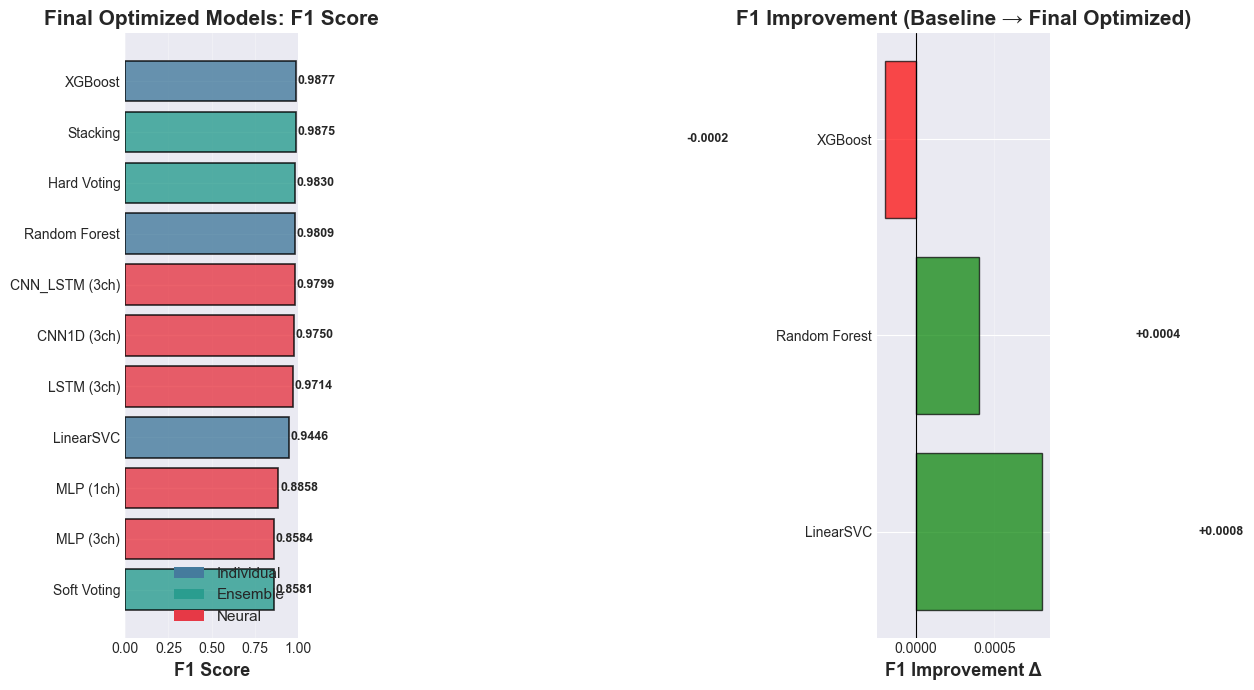


✓ Figure saved to /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/evaluation_figures/02_final_optimized_comparison.png


In [7]:
# Visualization: Final optimized models ranked by F1

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

final_sorted = final_comparison.sort_values('Final F1', ascending=True)

# Color by type
color_map = {'Individual': '#457B9D', 'Ensemble': '#2A9D8F', 'Neural': '#E63946'}
colors = final_sorted['Type'].map(color_map)

# Plot 1: Final F1 Score (all models)
bars = axes[0].barh(final_sorted['Model'], final_sorted['Final F1'], 
                    color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

axes[0].set_xlabel('F1 Score', fontsize=13, fontweight='bold')
axes[0].set_title('Final Optimized Models: F1 Score', fontsize=15, fontweight='bold')
axes[0].set_xlim(0, 1.0)
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(final_sorted.iterrows()):
    axes[0].text(row['Final F1'] + 0.01, i, f"{row['Final F1']:.4f}", 
                va='center', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#457B9D', label='Individual'),
    Patch(facecolor='#2A9D8F', label='Ensemble'),
    Patch(facecolor='#E63946', label='Neural')
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=11)

# Plot 2: F1 Improvement Δ (only for models with baseline)
with_baseline = final_sorted[~final_sorted['F1 Δ'].isna()].copy()

if not with_baseline.empty:
    colors_delta = ['green' if val > 0 else 'red' for val in with_baseline['F1 Δ']]
    bars2 = axes[1].barh(with_baseline['Model'], with_baseline['F1 Δ'], 
                         color=colors_delta, alpha=0.7, edgecolor='black')
    
    axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[1].set_xlabel('F1 Improvement Δ', fontsize=13, fontweight='bold')
    axes[1].set_title('F1 Improvement (Baseline → Final Optimized)', fontsize=15, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (idx, row) in enumerate(with_baseline.iterrows()):
        offset = 0.001 if row['F1 Δ'] > 0 else -0.001
        ha = 'left' if row['F1 Δ'] > 0 else 'right'
        axes[1].text(row['F1 Δ'] + offset, i, f"{row['F1 Δ']:+.4f}", 
                    va='center', ha=ha, fontsize=9, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No baseline comparisons available', 
                ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('F1 Improvement Δ', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_final_optimized_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n✓ Figure saved to {OUTPUT_DIR / "02_final_optimized_comparison.png"}')

## 5. Best Model Per Algorithm Comparison

Compare the best performing variant of each algorithm type.

In [8]:
# Identify best model per algorithm family

def get_best_per_algorithm():
    """Get best performing model for each algorithm type"""
    
    best_models = []
    
    # Classical algorithms - use final optimized results
    algorithms = ['XGBoost', 'Random Forest', 'LinearSVC', 'Gradient Boosting', 'KNN', 'GMM']
    
    for algo in algorithms:
        # Search in final optimized (all feature sets and types)
        matches = final_optimized[final_optimized['Model'] == algo]
        
        if not matches.empty:
            # Get best F1 across all feature sets
            best_idx = matches['Test F1'].idxmax()
            best = matches.loc[best_idx]
            
            best_models.append({
                'Algorithm': algo,
                'Model': f"{algo} ({best['Feature Set']})",
                'Test Acc': best['Test Accuracy'],
                'Test F1': best['Test F1'],
                'Source': f"Optimized ({best['Feature Set']})",
                'Type': best['Type']
            })
    
    # Add best ensemble
    ensembles = final_optimized[final_optimized['Type'] == 'Ensemble']
    if not ensembles.empty:
        best_ens_idx = ensembles['Test F1'].idxmax()
        best_ens = ensembles.loc[best_ens_idx]
        
        best_models.append({
            'Algorithm': 'Ensemble',
            'Model': f"{best_ens['Model']} ({best_ens['Feature Set']})",
            'Test Acc': best_ens['Test Accuracy'],
            'Test F1': best_ens['Test F1'],
            'Source': f"Ensemble ({best_ens['Feature Set']})",
            'Type': 'Ensemble'
        })
    
    # Add best neural (1ch)
    best_1ch_idx = neural_1ch['F1'].idxmax()
    best_1ch = neural_1ch.loc[best_1ch_idx]
    
    best_models.append({
        'Algorithm': 'Neural Network',
        'Model': f"{best_1ch['Model']} (1ch)",
        'Test Acc': best_1ch['Accuracy'],
        'Test F1': best_1ch['F1'],
        'Source': 'Neural (1ch)',
        'Type': 'Neural'
    })
    
    # Add best neural (3ch) if available
    if neural_3ch is not None:
        best_3ch_idx = neural_3ch['F1'].idxmax()
        best_3ch = neural_3ch.loc[best_3ch_idx]
        
        best_models.append({
            'Algorithm': 'Neural Network (3ch)',
            'Model': f"{best_3ch['Model']} (3ch)",
            'Test Acc': best_3ch['Accuracy'],
            'Test F1': best_3ch['F1'],
            'Source': 'Neural (3ch)',
            'Type': 'Neural'
        })
    
    return pd.DataFrame(best_models)

best_per_algo = get_best_per_algorithm()

# Display table
print('\n' + '='*90)
print('BEST MODEL PER ALGORITHM')
print('='*90 + '\n')

display(best_per_algo.sort_values('Test F1', ascending=False).round(4))


BEST MODEL PER ALGORITHM



,Algorithm,Model,Test Acc,Test F1,Source,Type
0,XGBoost,XGBoost (COMBINED),0.9864,0.9877,Optimized (COMBINED),Individual
3,Ensemble,Stacking (COMBINED),0.9863,0.9875,Ensemble (COMBINED),Ensemble
1,Random Forest,Random Forest (COMBINED),0.9789,0.9809,Optimized (COMBINED),Individual
5,Neural Network (3ch),CNN_LSTM (3ch),0.9779,0.9799,Neural (3ch),Neural
2,LinearSVC,LinearSVC (COMBINED),0.9392,0.9446,Optimized (COMBINED),Individual
4,Neural Network,MLP (1ch),0.8724,0.8858,Neural (1ch),Neural


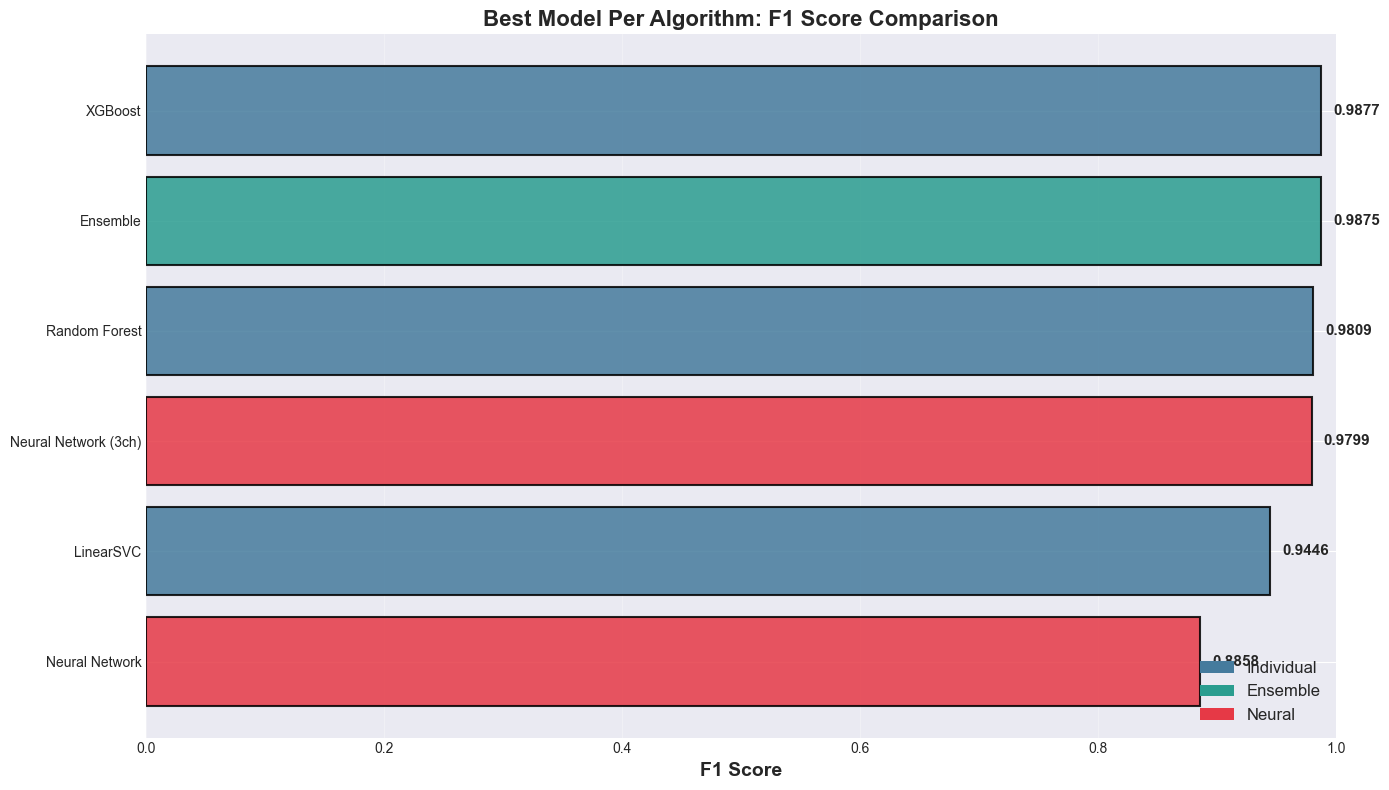


✓ Figure saved to /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/evaluation_figures/03_best_per_algorithm.png


In [9]:
# Best per algorithm bar chart

fig, ax = plt.subplots(1, 1, figsize=(14, 8))

best_sorted = best_per_algo.sort_values('Test F1', ascending=True)

# Color by type
type_color_map = {'Individual': '#457B9D', 'Ensemble': '#2A9D8F', 'Neural': '#E63946'}
colors = best_sorted['Type'].map(type_color_map)

# Plot F1 Score
bars = ax.barh(best_sorted['Algorithm'], best_sorted['Test F1'], 
               color=colors, alpha=0.85, edgecolor='black', linewidth=1.5)

ax.set_xlabel('F1 Score', fontsize=14, fontweight='bold')
ax.set_title('Best Model Per Algorithm: F1 Score Comparison', fontsize=16, fontweight='bold')
ax.set_xlim(0, 1.0)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(best_sorted.iterrows()):
    ax.text(row['Test F1'] + 0.01, i, f"{row['Test F1']:.4f}", 
            va='center', fontsize=11, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#457B9D', label='Individual'),
    Patch(facecolor='#2A9D8F', label='Ensemble'),
    Patch(facecolor='#E63946', label='Neural')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_best_per_algorithm.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n✓ Figure saved to {OUTPUT_DIR / "03_best_per_algorithm.png"}')

## 6. Confusion Matrices

Generate confusion matrices for:
1. Best baseline model
2. Best overall model (final optimized)

In [10]:
# Load test data and labels

print('Loading test data for confusion matrix generation...')

features_dir = DATA_DIR / 'features' / 'classical'

# Try various naming conventions
test_paths = [
    (features_dir / 'combined_test_features.npy', features_dir / 'test_labels.npy'),
    (features_dir / 'X_test_combined.npy', features_dir / 'y_test.npy'),
    (features_dir / 'X_test.npy', features_dir / 'y_test.npy')
]

X_test, y_test = None, None
test_data_available = False

for x_path, y_path in test_paths:
    if x_path.exists() and y_path.exists():
        X_test = np.load(x_path)
        y_test = np.load(y_path)
        print(f'✓ Test data loaded: {X_test.shape[0]} samples')
        print(f'  From: {x_path.name} and {y_path.name}')
        test_data_available = True
        break

if not test_data_available:
    print('⚠️  Test data files not found.')
    print('   Run notebooks 03 and 05 first to generate test data.')

Loading test data for confusion matrix generation...
⚠️  Test data files not found.
   Run notebooks 03 and 05 first to generate test data.


In [11]:
if test_data_available:
    # Find best baseline model (classical only for CM)
    classical_baseline = baseline_comparison[baseline_comparison['Type'] == 'Classical']
    
    if not classical_baseline.empty:
        best_baseline_idx = classical_baseline['F1'].idxmax()
        best_baseline_name = classical_baseline.loc[best_baseline_idx, 'Model']
        
        print(f'\nBest baseline model: {best_baseline_name}')
        print(f'  F1 Score: {classical_baseline.loc[best_baseline_idx, "F1"]:.4f}')
        
        # Find best overall classical model
        classical_final = final_comparison[final_comparison['Type'].isin(['Individual', 'Ensemble'])]
        
        if not classical_final.empty:
            best_overall_idx = classical_final['Final F1'].idxmax()
            best_overall_name = classical_final.loc[best_overall_idx, 'Model']
            
            print(f'\nBest overall model: {best_overall_name}')
            print(f'  F1 Score: {classical_final.loc[best_overall_idx, "Final F1"]:.4f}')
            
            # Load models
            baseline_model_paths = [
                MODELS_DIR / 'classical' / f'{best_baseline_name.lower().replace(" ", "_")}_combined.pkl',
                MODELS_DIR / 'classical' / f'{best_baseline_name.lower().replace(" ", "_")}_baseline_combined.pkl'
            ]
            
            baseline_model = None
            for path in baseline_model_paths:
                if path.exists():
                    baseline_model = joblib.load(path)
                    print(f'\n✓ Loaded baseline model from {path.name}')
                    break
            
            if baseline_model is None:
                print(f'⚠️  Baseline model not found')
            
            # Load optimized model
            # Extract base model name (remove ensemble prefixes)
            base_name = best_overall_name.replace('Stacking', '').replace('Soft Voting', '').replace('Hard Voting', '').strip()
            
            optimized_model_paths = [
                MODELS_DIR / 'classical' / f'{best_overall_name.lower().replace(" ", "_")}_combined.pkl',
                MODELS_DIR / 'classical' / f'{base_name.lower().replace(" ", "_")}_tuned_combined.pkl',
                MODELS_DIR / 'classical' / f'{base_name.lower().replace(" ", "_")}_optimized_combined.pkl'
            ]
            
            optimized_model = None
            for path in optimized_model_paths:
                if path.exists():
                    optimized_model = joblib.load(path)
                    print(f'✓ Loaded optimized model from {path.name}')
                    break
            
            if optimized_model is None:
                print(f'⚠️  Optimized model not found')
            
            # Load scaler
            scaler_path = MODELS_DIR / 'classical' / 'scaler_combined.pkl'
            if scaler_path.exists():
                scaler = joblib.load(scaler_path)
                X_test_scaled = scaler.transform(X_test)
                print(f'✓ Loaded and applied scaler')
            else:
                print(f'⚠️  Scaler not found, using unscaled features')
                X_test_scaled = X_test
        else:
            baseline_model = None
            optimized_model = None
    else:
        baseline_model = None
        optimized_model = None
else:
    baseline_model = None
    optimized_model = None

In [12]:
if test_data_available and baseline_model is not None and optimized_model is not None:
    
    # Generate predictions
    y_pred_baseline = baseline_model.predict(X_test_scaled)
    y_pred_optimized = optimized_model.predict(X_test_scaled)
    
    # Compute confusion matrices
    cm_baseline = confusion_matrix(y_test, y_pred_baseline)
    cm_optimized = confusion_matrix(y_test, y_pred_optimized)
    
    # Class names
    class_names = ['Background', 'Grinder', 'Tools']
    if len(np.unique(y_test)) == 2:
        class_names = ['Non-Grinder', 'Grinder']
    
    # Plot confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Baseline confusion matrix
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=class_names)
    disp1.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
    axes[0].set_title(f'Best Baseline Model\n{best_baseline_name}\nF1: {classical_baseline.loc[best_baseline_idx, "F1"]:.4f}', 
                     fontsize=13, fontweight='bold')
    axes[0].grid(False)
    
    # Optimized confusion matrix
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_optimized, display_labels=class_names)
    disp2.plot(ax=axes[1], cmap='Greens', values_format='d', colorbar=False)
    axes[1].set_title(f'Best Overall Model\n{best_overall_name}\nF1: {classical_final.loc[best_overall_idx, "Final F1"]:.4f}', 
                     fontsize=13, fontweight='bold')
    axes[1].grid(False)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '04_confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f'\n✓ Confusion matrices saved to {OUTPUT_DIR / "04_confusion_matrices.png"}')

## 7. Summary and Recommendations

In [13]:
# Generate comprehensive summary

print('\n' + '='*80)
print('COMPREHENSIVE MODEL EVALUATION SUMMARY')
print('='*80 + '\n')

# Best baseline
best_baseline = baseline_comparison.loc[baseline_comparison['F1'].idxmax()]
print(f'🥇 BEST BASELINE MODEL:')
print(f'   Model: {best_baseline["Model"]} ({best_baseline["Type"]})') 
print(f'   F1 Score: {best_baseline["F1"]:.4f}')
print(f'   Accuracy: {best_baseline["Accuracy"]:.4f}')

# Best overall
best_overall = final_comparison.loc[final_comparison['Final F1'].idxmax()]
print(f'🏆 BEST OVERALL MODEL (final optimized):')
print(f'   Model: {best_overall["Model"]} ({best_overall["Type"]})') 
print(f'   F1 Score: {best_overall["Final F1"]:.4f}')
print(f'   Accuracy: {best_overall["Final Acc"]:.4f}')

if not pd.isna(best_overall['F1 Δ']):
    print(f'   Improvement from baseline: +{best_overall["F1 Δ"]:.4f} ({best_overall["F1 Δ %"]:.2f}%)')

# Top 5 models overall
print(f'\n📊 TOP 5 MODELS (by F1 Score):')

top_5 = final_comparison.nlargest(5, 'Final F1')

for rank, (idx, row) in enumerate(top_5.iterrows(), 1):
    print(f'   {rank}. {row["Model"]}: F1={row["Final F1"]:.4f}, Acc={row["Final Acc"]:.4f}')

print('\n' + '='*80)

print('\n💡 RECOMMENDATIONS FOR DEPLOYMENT:\n')
print('   • For highest accuracy: Use best overall model (ensembles if available)')
print('   • For embedded deployment: Consider model size vs performance trade-off')
print('   • For real-time: Check inference times in 06a_inference_times.csv')
print('   • Best neural options: Check both 1ch and 3ch results')
print('   • Next steps: Quantization and embedded optimization (Notebook 09)')

print('✓ Evaluation complete!')


COMPREHENSIVE MODEL EVALUATION SUMMARY

🥇 BEST BASELINE MODEL:
   Model: XGBoost (Classical)
   F1 Score: 0.9879
   Accuracy: 0.9866
🏆 BEST OVERALL MODEL (final optimized):
   Model: XGBoost (Individual)
   F1 Score: 0.9877
   Accuracy: 0.9864
   Improvement from baseline: +-0.0002 (-0.02%)

📊 TOP 5 MODELS (by F1 Score):
   1. XGBoost: F1=0.9877, Acc=0.9864
   2. Stacking: F1=0.9875, Acc=0.9863
   3. Hard Voting: F1=0.9830, Acc=0.9812
   4. Random Forest: F1=0.9809, Acc=0.9789
   5. CNN_LSTM (3ch): F1=0.9799, Acc=0.9779


💡 RECOMMENDATIONS FOR DEPLOYMENT:

   • For highest accuracy: Use best overall model (ensembles if available)
   • For embedded deployment: Consider model size vs performance trade-off
   • For real-time: Check inference times in 06a_inference_times.csv
   • Best neural options: Check both 1ch and 3ch results
   • Next steps: Quantization and embedded optimization (Notebook 09)
✓ Evaluation complete!


In [14]:
# Save summary to JSON

summary = {
    'best_baseline': {
        'model': best_baseline['Model'],
        'type': best_baseline['Type'],
        'f1': float(best_baseline['F1']),
        'accuracy': float(best_baseline['Accuracy'])
    },
    'best_overall': {
        'model': best_overall['Model'],
        'type': best_overall['Type'],
        'f1': float(best_overall['Final F1']),
        'accuracy': float(best_overall['Final Acc']),
        'improvement_f1': float(best_overall['F1 Δ']) if not pd.isna(best_overall['F1 Δ']) else None,
        'improvement_percent': float(best_overall['F1 Δ %']) if not pd.isna(best_overall['F1 Δ %']) else None
    },
    'top_5_models': [
        {
            'model': row['Model'],
            'f1': float(row['Final F1']),
            'accuracy': float(row['Final Acc'])
        }
        for idx, row in top_5.iterrows()
    ]
}

summary_path = RESULTS_DIR / '10_evaluation_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\n✓ Summary saved to {summary_path}')


✓ Summary saved to /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/10_evaluation_summary.json
